# clw sensitivity test #1 — analysis

Protocol: `lf1e-clw-sensitivity-experiment-1.md`. Converts each variation's ClimaAtmos
output to Pithan2016 format via `scripts/convert_to_pithan.py`, compares against
`EC-Earth.nc`, builds the threshold/comparison tables, and plots profiles + time series.

In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "scripts"))
import convert_to_pithan as ctp

EXPERIMENT_DIR = REPO_ROOT / "experiments" / "clw sensitivity experiments"
VARIATION_OUTPUT_ROOT = EXPERIMENT_DIR / "output" / "lf1e-clw-1"
PITHAN_FORMAT_DIR = EXPERIMENT_DIR / "output" / "pithan_format"
EC_EARTH_PATH = REPO_ROOT / "Pithan 2016 Intercomparison Data" / "EC-Earth.nc"

SUFFIX = "1h_average"  # larcform1_1M_prognostic_edmfx.yml diagnoses everything at period: 1hours
CLW_THRESHOLD_KGKG = 1e-4  # 0.1 g/kg, Validation step 1
ANALYSIS_DAYS = 10

PITHAN_FORMAT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Discover variation output directories

Each variation lives under `output/lf1e-clw-1/v<N>_<name>/output_active/` (standalone
`ci_driver.jl` runs — files sit directly in the output dir, no `clima_atmos/` subdir).

In [11]:
def discover_variations(root: Path) -> dict[str, Path]:
    """Map variation name (e.g. 'v2_0M') -> its output_active dir."""
    variations = {}
    if not root.exists():
        return variations
    for child in sorted(root.iterdir()):
        active = child / "output_active"
        if active.exists():
            variations[child.name] = active
    return variations


variations = discover_variations(VARIATION_OUTPUT_ROOT)
print(f"Found {len(variations)} variation(s) under {VARIATION_OUTPUT_ROOT}")
for name, path in variations.items():
    print(f"  {name}: {path}")

Found 0 variation(s) under /Users/jeff/clima/larcform1-experiments/experiments/clw sensitivity experiments/output/lf1e-clw-1


## 2. Convert each variation to Pithan2016 format

Reuses `scripts/convert_to_pithan.py::convert`, which already renames ClimaAtmos
variables into EC-Earth's naming convention (`hus`→`q`, `ta`→`t`, `pfull`→`p`,
`hur`→`rh`, `lwp`→`clwvi`, derives `precr` from `pr − prsn`) and fixes sign conventions.
Passing `--suffix`/`SUFFIX` explicitly since the script's default (`3h_average`) doesn't
match our `1hours` diagnostic period.

In [12]:
ctp._SUFFIX = SUFFIX

converted_paths = {}
for name, nc_dir in variations.items():
    out_path = PITHAN_FORMAT_DIR / f"{name}.nc"
    ctp.convert(nc_dir, model_name=name, out_path=out_path)
    converted_paths[name] = out_path

## 3. Load EC-Earth reference data

Sanity-check the `clw`/`cli` units before trusting comparisons — EC-Earth labels them
dimensionless (`"1"`); confirm the magnitude matches ClimaAtmos's kg/kg mixing ratios
rather than some other normalization. Also confirm `ps` (and thus `p(nlev)`) is
time-invariant, which is what lets us regrid onto a single fixed pressure grid instead of
per-timestep.

In [13]:
ec_earth = xr.open_dataset(EC_EARTH_PATH, decode_times=False)

ps_range = (float(ec_earth["ps"].min()), float(ec_earth["ps"].max()))
print(f"EC-Earth ps range: {ps_range} Pa (expect constant -> fixed pressure grid)")

print(f"EC-Earth clw range: {float(ec_earth['clw'].min()):.3e} to {float(ec_earth['clw'].max()):.3e}")
print(f"EC-Earth cli range: {float(ec_earth['cli'].min()):.3e} to {float(ec_earth['cli'].max()):.3e}")

# Fixed pressure grid (single time slice; p(nlev) does not vary in time for EC-Earth)
ec_earth_p = ec_earth["p"].isel(time=0).values
print(f"EC-Earth pressure levels: {ec_earth_p.min():.1f} to {ec_earth_p.max():.1f} Pa, {len(ec_earth_p)} levels")

EC-Earth ps range: (101300.0, 101300.0) Pa (expect constant -> fixed pressure grid)
EC-Earth clw range: -7.100e-28 to 6.809e-04
EC-Earth cli range: 0.000e+00 to 3.604e-05
EC-Earth pressure levels: 10.0 to 101180.0 Pa, 60 levels


## 4. Pressure regrid helper

ClimaAtmos's `lev` coordinate (from the converter) is z-height, not pressure, and its
stretched grid doesn't line up level-for-level with EC-Earth's `nlev`. Both sides carry
their own `p(time, lev)`, so interpolate profile variables onto EC-Earth's fixed pressure
grid using each timestep's own `p` before comparing.

In [14]:
def regrid_to_pressure(ds: xr.Dataset, var: str, target_p: np.ndarray) -> xr.DataArray:
    """Interpolate ds[var] (time, lev) from its own p(time, lev) onto target_p (Pa).

    target_p must be ascending or descending consistently with ds['p'] per timestep.
    Returns a (time, plev) DataArray.
    """
    da = ds[var]
    p = ds["p"]
    n_time = da.sizes["time"]
    out = np.empty((n_time, len(target_p)))
    for t in range(n_time):
        p_t = p.isel(time=t).values
        v_t = da.isel(time=t).values
        order = np.argsort(p_t)
        out[t, :] = np.interp(target_p, p_t[order], v_t[order])
    return xr.DataArray(
        out,
        dims=("time", "plev"),
        coords={"time": da.coords["time"], "plev": target_p},
        attrs=da.attrs,
    )


def restrict_to_first_n_days(ds: xr.Dataset, n_days: int = ANALYSIS_DAYS) -> xr.Dataset:
    """Both converted ClimaAtmos files and EC-Earth use seconds-since-start time."""
    cutoff = n_days * 86400
    return ds.sel(time=ds["time"] <= cutoff)

## 5. Check tables

In [15]:
def clw_threshold_row(name: str, path: Path) -> dict:
    ds = restrict_to_first_n_days(xr.open_dataset(path, decode_times=False))
    max_clw = float(ds["clw"].max())
    return {
        "variation": name,
        "max_clw_kgkg": max_clw,
        "passes_threshold": max_clw > CLW_THRESHOLD_KGKG,
        "notes": "",
    }


threshold_rows = [clw_threshold_row(name, path) for name, path in converted_paths.items()]
threshold_table = pd.DataFrame(
    threshold_rows, columns=["variation", "max_clw_kgkg", "passes_threshold", "notes"]
)
if threshold_table.empty:
    print("No converted variations yet -- run the variations and re-execute from cell 2.")
else:
    threshold_table = threshold_table.sort_values("variation")
threshold_table

No converted variations yet -- run the variations and re-execute from cell 2.


,variation,max_clw_kgkg,passes_threshold,notes


In [16]:
# Extended comparison table (Validation steps 2-8) — only for variations passing step 1
PROFILE_COMPARISON_VARS = ["cli", "q", "rh"]
SURFACE_COMPARISON_VARS = ["clwvi", "clivi", "precr", "precs"]


def mean_bias(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.nanmean(a - b))


def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.nanmean((a - b) ** 2)))


def comparison_row(name: str, path: Path, ec_earth_10d: xr.Dataset, target_p: np.ndarray) -> dict:
    ds = restrict_to_first_n_days(xr.open_dataset(path, decode_times=False))
    row = {"variation": name}
    for var in PROFILE_COMPARISON_VARS:
        model_p = regrid_to_pressure(ds, var, target_p)
        ref_p = regrid_to_pressure(ec_earth_10d, var, target_p)
        row[f"{var}_bias"] = mean_bias(model_p.values, ref_p.values.mean(axis=0, keepdims=True))
        row[f"{var}_rmse"] = rmse(model_p.values, ref_p.values.mean(axis=0, keepdims=True))
    for var in SURFACE_COMPARISON_VARS:
        model_v = ds[var].values
        ref_v = ec_earth_10d[var].values
        n = min(len(model_v), len(ref_v))
        row[f"{var}_bias"] = mean_bias(model_v[:n], ref_v[:n])
        row[f"{var}_rmse"] = rmse(model_v[:n], ref_v[:n])
    return row


passing = [] if threshold_table.empty else threshold_table.loc[threshold_table["passes_threshold"], "variation"].tolist()
ec_earth_10d = restrict_to_first_n_days(ec_earth)

comparison_rows = [
    comparison_row(name, converted_paths[name], ec_earth_10d, ec_earth_p) for name in passing
]
comparison_table = pd.DataFrame(comparison_rows)
if comparison_table.empty:
    print("No variations passed the clw threshold yet (or none have been run).")
comparison_table

No variations passed the clw threshold yet (or none have been run).


""


## 6. Profile plots — day-1 time evolution, small multiples

One grid per variable (`t`, `q`, `rh`, `clw`, `cli`): one box per source (each
variation, plus EC-Earth as its own box), each box showing pressure-vs-value profiles
at 2-hour intervals across day 1 (12 profiles: 0h, 2h, ..., 22h). EC-Earth gets its own
panel rather than being overlaid into every variation's box — comparison is by
pattern-matching panels, which also shows whether a variation's cloud-formation
*timing* matches EC-Earth's, not just its mean level.

Color follows the dataviz-skill sequential rule: one hue, light→dark, for the
continuous "hours since start" quantity — a shared colorbar, not a 12-entry legend.

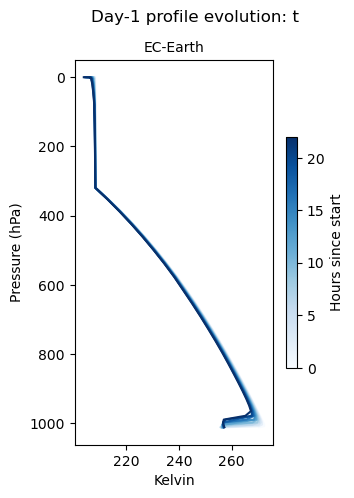

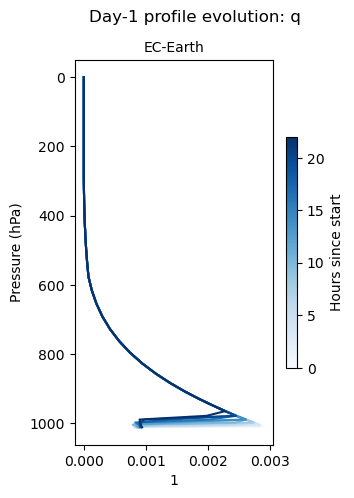

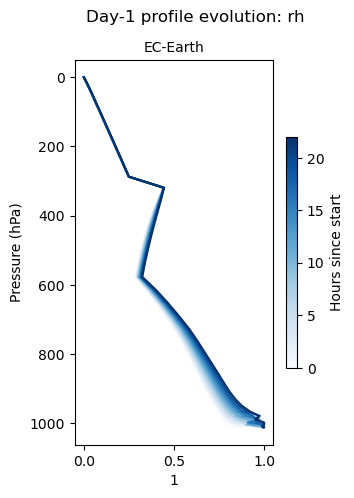

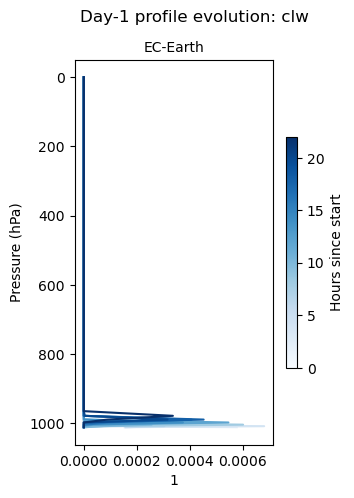

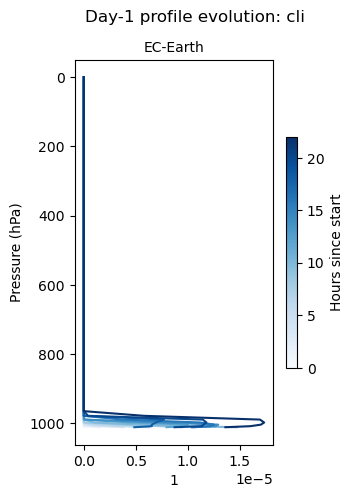

In [17]:
import math
import matplotlib.colors as mcolors

DAY1_HOURS = list(range(0, 24, 2))  # 0h, 2h, ..., 22h -- 12 profiles


def nearest_time_indices(ds: xr.Dataset, hours: list[int]) -> list[int]:
    """Index of the time step nearest to each hour (time coord is seconds since start)."""
    time_hours = ds["time"].values / 3600.0
    return [int(np.argmin(np.abs(time_hours - h))) for h in hours]


def load_converted(name: str) -> xr.Dataset:
    return xr.open_dataset(converted_paths[name], decode_times=False)


def plot_day1_evolution_grid(var: str, target_p: np.ndarray, hours: list[int] = DAY1_HOURS):
    """Small multiples: one box per source (each variation + EC-Earth), each box showing
    `var` profiles at 2-hour intervals across day 1, colored light->dark by hour."""
    sources = {name: load_converted(name) for name in converted_paths}
    sources["EC-Earth"] = ec_earth

    n = len(sources)
    ncols = min(5, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.2 * ncols, 5 * nrows), sharex=True, sharey=True, squeeze=False
    )
    axes = axes.flatten()

    cmap = plt.get_cmap("Blues")
    norm = mcolors.Normalize(vmin=min(hours), vmax=max(hours))

    for ax, (name, ds) in zip(axes, sources.items()):
        idxs = nearest_time_indices(ds, hours)
        profile_all = regrid_to_pressure(ds, var, target_p)
        for h, idx in zip(hours, idxs):
            ax.plot(profile_all.isel(time=idx).values, target_p / 100.0, color=cmap(norm(h)), linewidth=1.5)
        ax.set_title(name, fontsize=10)

    for ax in axes[n:]:
        ax.set_visible(False)

    axes[0].invert_yaxis()
    bottom_row_start = (nrows - 1) * ncols
    for i in range(bottom_row_start, n):
        axes[i].set_xlabel(ec_earth[var].attrs.get("units", ""))
    for i in range(0, n, ncols):
        axes[i].set_ylabel("Pressure (hPa)")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes[:n].tolist(), label="Hours since start", shrink=0.6)
    fig.suptitle(f"Day-1 profile evolution: {var}")
    return fig


for var in ["t", "q", "rh", "clw", "cli"]:
    plot_day1_evolution_grid(var, ec_earth_p)
    plt.show()

## 7. Time-series plots

Column-integrated / scalar diagnostics over the first 10 days.

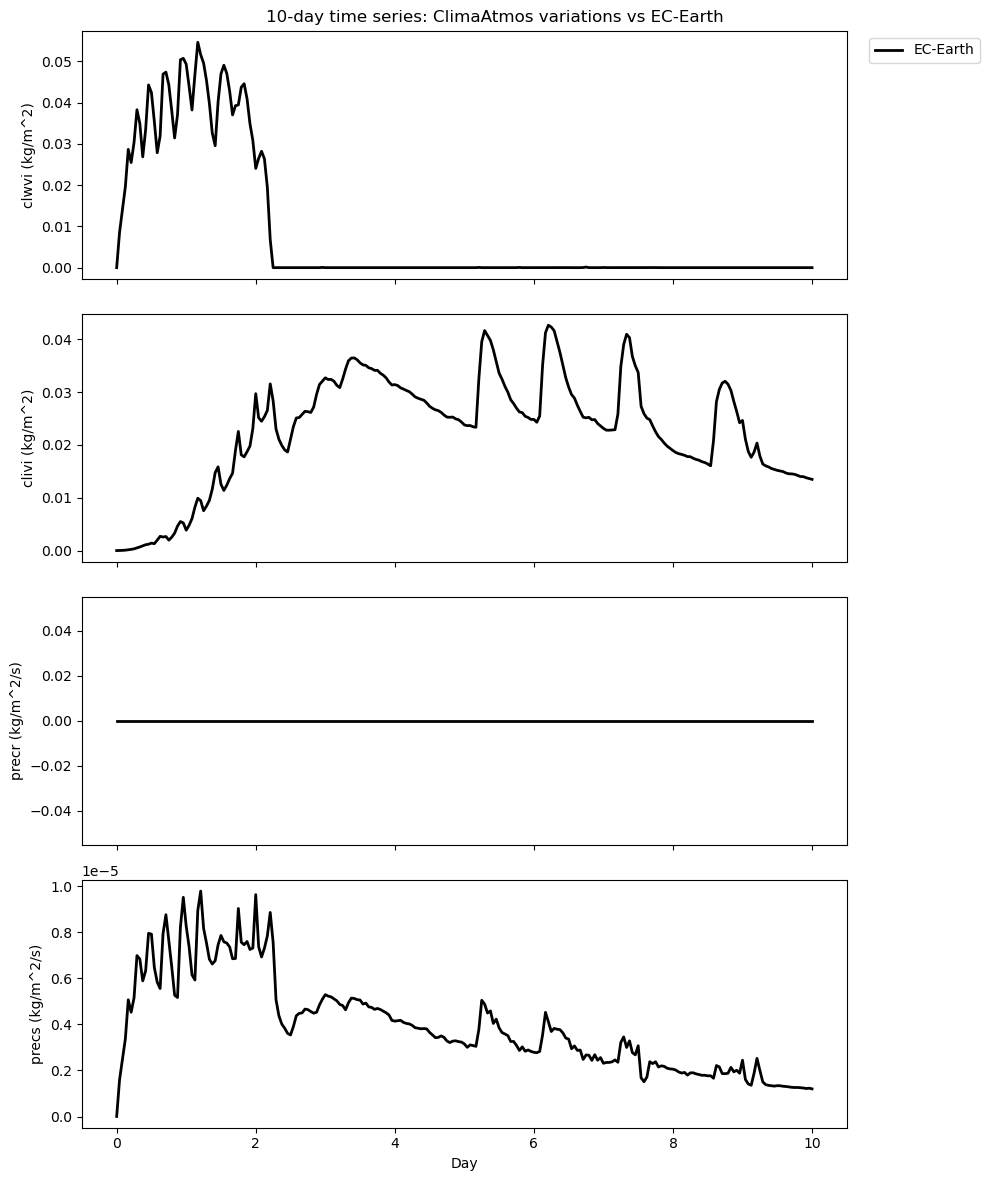

In [18]:
TIMESERIES_PLOT_VARS = ["clwvi", "clivi", "precr", "precs"]

fig, axes = plt.subplots(len(TIMESERIES_PLOT_VARS), 1, figsize=(10, 3 * len(TIMESERIES_PLOT_VARS)), sharex=True)

for ax, var in zip(axes, TIMESERIES_PLOT_VARS):
    ax.plot(ec_earth_10d["time"] / 86400.0, ec_earth_10d[var], label="EC-Earth", color="black", linewidth=2)
    for name in passing:
        ds = restrict_to_first_n_days(xr.open_dataset(converted_paths[name], decode_times=False))
        ax.plot(ds["time"] / 86400.0, ds[var], label=name, alpha=0.8)
    ax.set_ylabel(f"{var} ({ec_earth[var].attrs.get('units', '')})")

axes[-1].set_xlabel("Day")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.suptitle("10-day time series: ClimaAtmos variations vs EC-Earth")
fig.tight_layout()